Clustering with QAOA with only numpy and scipy

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import minimize
from scipy.linalg import expm
import networkx as nx
from numba import njit

[[0 1 1 1 0 0 0 0 0 0]
 [1 0 1 1 0 0 0 0 0 0]
 [1 1 0 1 0 0 0 0 0 0]
 [1 1 1 0 1 1 1 0 0 0]
 [0 0 0 1 0 1 1 0 0 0]
 [0 0 0 1 1 0 1 0 0 0]
 [0 0 0 1 1 1 0 1 1 0]
 [0 0 0 0 0 0 1 0 1 1]
 [0 0 0 0 0 0 1 1 0 1]
 [0 0 0 0 0 0 0 1 1 0]]


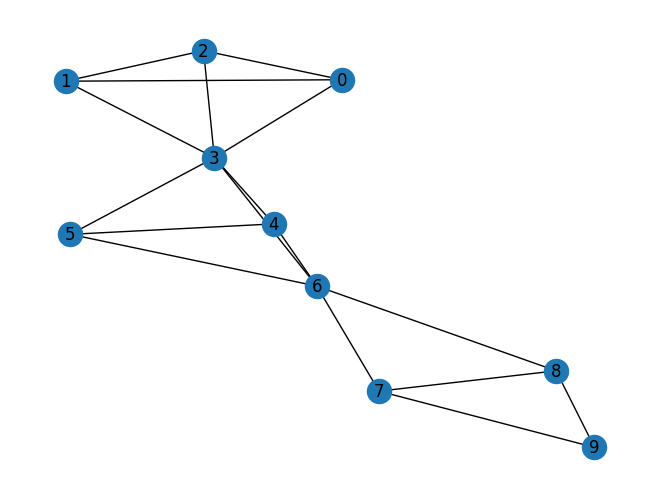

In [2]:
def add_edges(graph, edges):
    for edge in edges:
        graph.add_edge(edge[0], edge[1])

network_graph = nx.Graph()

edges = [(0, 1), (0, 2), (0, 3), (1, 2), (1, 3), (2, 3), (3, 4), (3, 5), (3, 6), (4, 5), (4, 6), (5, 6), (6, 7), (6, 8), (7, 8), (7, 9), (8, 9)]
add_edges(network_graph, edges)

A = np.array(nx.adjacency_matrix(network_graph).todense())
print(A)

nx.draw(network_graph, with_labels=True)
plt.show()

In [14]:
def build_k2_cluster(graph: nx.Graph, alpha: float) -> list:
    """Build the Pauli operator for the clustering problem."""
    num_nodes = len(graph.nodes)

    # Calculate the sum over all edges
    m = graph.size(weight='weight')
    
    # Calculate edge degree for each node
    k = np.zeros(num_nodes)
    for i in range(num_nodes):
        k[i] = graph.degree(i, weight='weight')

    pauli_list = []
    for i in range(num_nodes):
        for j in range(i + 1, num_nodes):
            # Add the modularity term
            edge_data = graph.get_edge_data(i, j)
            weight = edge_data.get('weight', 1) if edge_data else 0
            
            Q = weight - alpha*(k[i] * k[j]) / (2 * m)
            pauli_list.append(("ZZ", [i, j], Q))

    return pauli_list

@njit
def modularity_calc(A: np.array, alpha: float, z: np.array) -> float: 
    num_nodes = len(A)
    m = np.sum(A) / 2  # Since A is symmetric, we divide by 2 to get the actual number of edges

    k = np.zeros(num_nodes)
    for i in range(num_nodes):
        k[i] = np.sum(A[i])

    modularity = 0.0
    for i in range(num_nodes):
        for j in range(i + 1, num_nodes):
            if z[i] == z[j]:  # Only consider pairs in the same cluster
                modularity += A[i, j] - alpha*(k[i] * k[j]) / (2 * m)
            
    return modularity / (2 * m)

In [19]:
N_QUBITS = len(network_graph.nodes)
DIM = 2 ** N_QUBITS

# Pauli matrices
I = np.array([[1, 0], [0, 1]])
Z = np.array([[1, 0], [0, -1]])
CX = np.array([[1, 0, 0, 0],
               [0, 1, 0, 0],
               [0, 0, 0, 1],
               [0, 0, 1, 0]])

def single_gate(gate: np.ndarray, qi: int, n_qubits: int) -> np.ndarray:
    """Embed a single-qubit gate on qubit qi in an n-qubit system."""
    ops = [I] * n_qubits
    ops[n_qubits - 1 - qi] = gate
    result = ops[0]
    for o in ops[1:]:
        result = np.kron(result, o)
    return result

def cnot(qi: int, qj: int, n_qubits: int) -> np.ndarray:
    """Embed CNOT with control qi and target qj in an n-qubit system."""
    dim = 2**n_qubits
    result = np.zeros((dim, dim), dtype=complex)
    for state in range(dim):
        # Check control qubit qi (in big-endian convention)
        control_bit = (state >> qi) & 1
        if control_bit == 0:
            result[state, state] = 1.0      # control=0: do nothing
        else:
            # Flip target qubit qj
            flipped = state ^ (1 << qj)
            result[flipped, state] = 1.0    # control=1: flip target
    return result

def rzz(theta: float, qi: int, qj: int, n_qubits: int) -> np.ndarray:
    """
    R_ZZ(theta) = CNOT_ij . (I ⊗ Rz(theta)) . CNOT_ij
    Applied on qubits qi (control) and qj (target).
    """
    Rz = np.array([[np.exp(-1j * theta / 2), 0],
                   [0,  np.exp( 1j * theta / 2)]], dtype=complex)

    CNOT = cnot(qi, qj, n_qubits)
    RZ   = single_gate(Rz, qj, n_qubits)   # Rz acts on target qubit

    return CNOT @ RZ @ CNOT


def rx(theta: float, qubit: int, n_qubits: int) -> np.ndarray:
    """Embed single-qubit x-rotation on 'qubit' in n-qubit space."""
    Rx = np.array([[np.cos(theta / 2), -1j*np.sin(theta / 2)],
                   [-1j*np.sin(theta / 2), np.cos(theta / 2)]], dtype=complex)

    return single_gate(Rx, qubit, n_qubits)

In [ ]:
# -----------------------------------------------------------------------------
# Functions for testing the correctness of the above implementations
# -----------------------------------------------------------------------------
def kron_two(op_i: np.ndarray, qi: int, op_j: np.ndarray, qj: int, n_qubits: int) -> np.ndarray:
    """Embed two single-qubit operators on different qubits."""
    ops = [I] * n_qubits
    ops[n_qubits - 1 - qi] = op_i
    ops[n_qubits - 1 - qj] = op_j
    result = ops[0]
    for o in ops[1:]:
        result = np.kron(result, o)
    return result

def rzz_direct(theta: float, qi: int, qj: int, n_qubits: int) -> np.ndarray:
    """Direct matrix exponential e^{-i theta/2 Z_i Z_j} for comparison."""
    ZZ = kron_two(Z, qi, Z, qj, n_qubits)
    return expm(-1j * theta / 2 * ZZ)

def rx_direct(theta: float, qi: int, n_qubits: int) -> np.ndarray:
    """Direct matrix exponential e^{-i theta/2 X_i} for comparison."""
    X_op = single_gate(X, qi, n_qubits)
    return expm(-1j * theta / 2 * X_op)

# Test the rzz implementation against the direct matrix exponential
from scipy.linalg import expm
theta = 0.7
n = 3
diff = np.max(np.abs(rzz(theta, 0, 1, n) - rzz_direct(theta, 0, 1, n)))
print(f"Max difference: {diff:.2e}")  # Should be ~1e-16

# Test the rx implementation against a direct matrix exponential
theta = 0.7
n = 3
diff = np.max(np.abs(rx(theta, 0, n) - rx_direct(theta, 0, n)))
print(f"Max difference: {diff:.2e}")  # Should be ~1e-16

Max difference: 0.00e+00
Max difference: 5.55e-17


In [16]:
# Hamiltonian plotting: 
def fmt(x):
    """Format complex number: show only non-zero parts, 2 decimals."""
    r, i = round(x.real, 2), round(x.imag, 2)
    if r == 0 and i == 0:
        return "0.00"
    elif i == 0:
        return f"{r:.2f}"
    elif r == 0:
        return f"{i:.2f}j"
    else:
        return f"{r:.2f}+{i:.2f}j"

def print_matrix(M, label, size=4):
    print(f"{label}:")
    for row in M[:size, :size]:
        print("  " + "  ".join(fmt(x) for x in row))
    print()

In [20]:
# ------------------------------------------------------------------------------
# The main QAOA functions to build the cost and mixer unitaries, construct the state, and compute expectation values.
# ------------------------------------------------------------------------------

def build_cost_unitary(pauli_list, N_QUBITS, gamma):
    """U_c(gamma) = product of RZZ gates for all edges."""
    U = np.eye(2**N_QUBITS, dtype=complex)
    for op, qubits, coeff in pauli_list:
        if op == "ZZ":
            U = rzz(gamma * coeff, qubits[0], qubits[1], N_QUBITS) @ U
    return U

def build_mixer_unitary(N_QUBITS, beta):
    """U_m(beta) = product of RX gates on all qubits."""
    U = np.eye(2**N_QUBITS, dtype=complex)
    for i in range(N_QUBITS):
        U = rx(beta, i, N_QUBITS) @ U
    return U

def build_qaoa_state(pauli_list, N_QUBITS, p, gammas, betas):
    """
    Build the QAOA state |psi(gamma, beta)> for p layers.
    gammas, betas: arrays of length p.
    """
    # Initial state: uniform superposition |+>^n
    dim = 2**N_QUBITS
    plus = np.ones(dim, dtype=complex) / np.sqrt(dim)

    state = plus.copy()
    for k in range(p):
        U_c = build_cost_unitary(pauli_list, N_QUBITS, gammas[k])
        U_m = build_mixer_unitary(N_QUBITS, betas[k])
        state = U_m @ U_c @ state  # apply cost first, then mixer

    return state

def expectation_value(state, H_c):
    """<psi|H_c|psi>"""
    return np.real(state.conj() @ H_c @ state)

# Build the bare cost Hamiltonian (not multiplied by gamma)
def build_cost_hamiltonian(pauli_list, N_QUBITS):
    H = np.zeros((2**N_QUBITS, 2**N_QUBITS), dtype=complex)
    for op, qubits, coeff in pauli_list:
        if op == "ZZ":
            H += coeff * kron_two(Z, qubits[0], Z, qubits[1], N_QUBITS)
    return H

p = 1
gammas = np.array([1.0])
betas  = np.array([1.0])

pauli_list = build_k2_cluster(network_graph, alpha=1.0)
H_c = build_cost_hamiltonian(pauli_list, N_QUBITS)

state = build_qaoa_state(pauli_list, N_QUBITS, p, gammas, betas)
print(f"<H_c> = {expectation_value(state, H_c):.4f}")

print_matrix(H_c[:4, :4], "H_c (first 4x4 block)")

<H_c> = -1.4431
H_c (first 4x4 block):
  -15.12  0.00  0.00  0.00
  0.00  -9.65  0.00  0.00
  0.00  0.00  -9.65  0.00
  0.00  0.00  0.00  -5.24



In [ ]:
# ------------------------------------------------------------------------------
# Shot based QAOA sampling
# ------------------------------------------------------------------------------
initial_state = np.ones(DIM) / np.sqrt(DIM)  # |+> state for all qubits
p = 1
gamma = 1.0
beta = 1.0


Brute-force optimal k-cluster modularity Q c calculation: 

-----------------------------


Optimal 2-cluster partition (Q = 0.2137)
  Cluster 0 (4 nodes): [0, 1, 2, 3]
  Cluster 1 (6 nodes): [4, 5, 6, 7, 8, 9]
  Labelling: [0, 0, 0, 0, 1, 1, 1, 1, 1, 1]

Optimal 3-cluster partition (Q = 0.2310)
  Cluster 0 (4 nodes): [0, 1, 2, 3]
  Cluster 1 (3 nodes): [4, 5, 6]
  Cluster 2 (3 nodes): [7, 8, 9]
  Labelling: [0, 0, 0, 0, 1, 1, 1, 2, 2, 2]

Optimal 4-cluster partition (Q = 0.2007)
  Cluster 0 (4 nodes): [0, 1, 2, 3]
  Cluster 1 (1 nodes): [4]
  Cluster 2 (1 nodes): [5]
  Cluster 3 (4 nodes): [6, 7, 8, 9]
  Labelling: [0, 0, 0, 0, 1, 2, 3, 3, 3, 3]

Optimal 5-cluster partition (Q = 0.1765)
  Cluster 0 (4 nodes): [0, 1, 2, 3]
  Cluster 1 (1 nodes): [4]
  Cluster 2 (1 nodes): [5]
  Cluster 3 (1 nodes): [6]
  Cluster 4 (3 nodes): [7, 8, 9]
  Labelling: [0, 0, 0, 0, 1, 2, 3, 4, 4, 4]


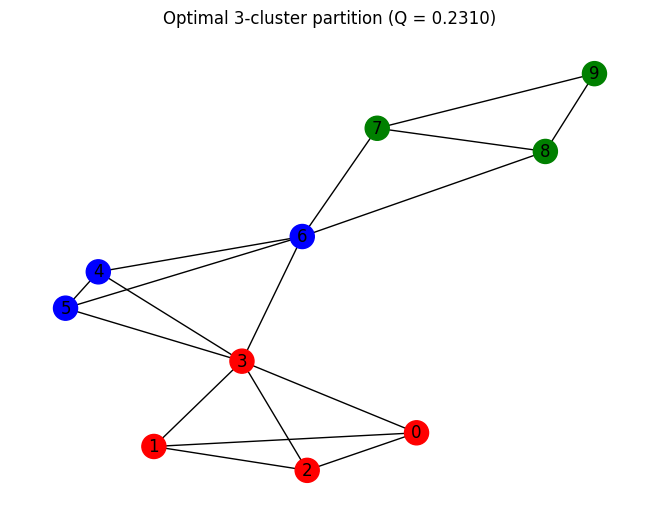

In [41]:
from itertools import product

print("Brute-force optimal k-cluster modularity Q c calculation: \n")
print("-----------------------------\n")

for n_clusters in [2, 3, 4, 5]:
    best_val = -np.inf
    best_config = None

    # Enumerate all n_clusters^N_QUBITS labellings
    # To avoid counting permutations of labels as different solutions,
    # we fix node 0 to cluster 0 (breaks label symmetry)
    for z in product(range(n_clusters), repeat=N_QUBITS - 1):
        z_full = np.array([0] + list(z), dtype=int)

        # Skip configurations that don't use all n_clusters labels
        # (those are really k<n_clusters partitions)
        if len(np.unique(z_full)) < n_clusters:
            continue

        obj_val = modularity_calc(A, alpha=1.0, z=z_full)
        if obj_val > best_val:
            best_val = obj_val
            best_config = z_full.copy()

    # Summary
    print(f"\nOptimal {n_clusters}-cluster partition (Q = {best_val:.4f})")
    for c in range(n_clusters):
        nodes = np.where(best_config == c)[0].tolist()
        print(f"  Cluster {c} ({len(nodes)} nodes): {nodes}")
    print(f"  Labelling: {best_config.tolist()}")

    if n_clusters == 3:
        best_3_config = best_config.copy()
        best_3_val = best_val

# Plot
cmap = ['red', 'blue', 'green', 'orange', 'purple']
color_map = [cmap[best_3_config[i]] for i in range(N_QUBITS)]
plt.figure()
nx.draw(network_graph, with_labels=True, node_color=color_map)
plt.title(
    f"Optimal 3-cluster partition (Q = {best_3_val:.4f})"
)
plt.show()